<a href="https://www.kaggle.com/code/vaibhavmishra1199/notebook676c947e63?scriptVersionId=332177734" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

import numpy as np 
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


 # **Confusion matrix**

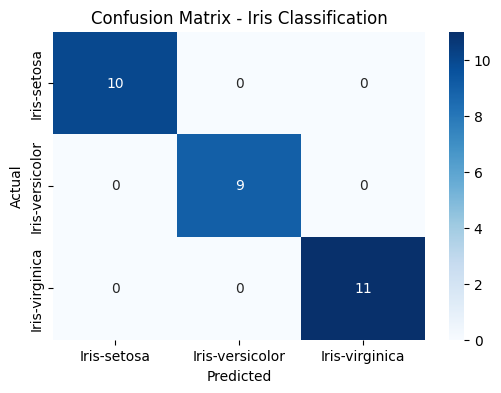

In [2]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv') 

# 2. Features and Target 
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# 3. Data ko train aur test mein split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model ko train karna
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 5. Predictions nikalna
y_pred = model.predict(X_test)

# 6. Confusion Matrix banana aur plot karna
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Iris Classification')
plt.show()

# **prediction**

In [3]:
# new flower  (SepalLength, SepalWidth, PetalLength, PetalWidth)
new_flower = [[5.1, 3.5, 1.4, 0.2]] 

# Model prediction
prediction = model.predict(new_flower)
print(f"Is flower species : {prediction[0]}")

Is flower species : Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


****

#  **Final model verification**

====== MODEL PERFORMANCE REPORT ======
Logistic Regression       -> Accuracy: 100.00%
Decision Tree             -> Accuracy: 100.00%
Support Vector Machine    -> Accuracy: 100.00%



/tmp/ipykernel_16/2417476800.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='coolwarm')


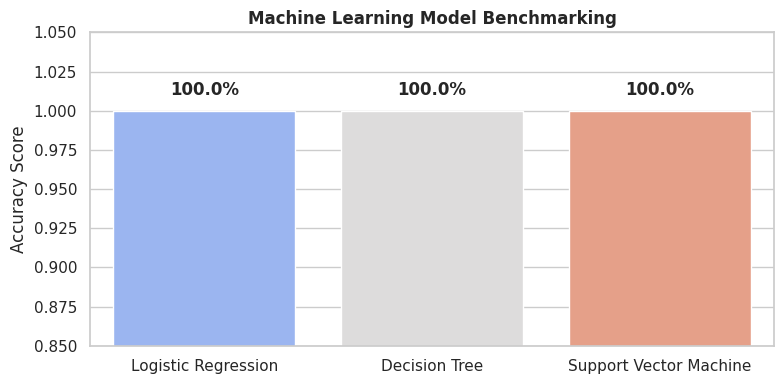

/tmp/ipykernel_16/2417476800.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


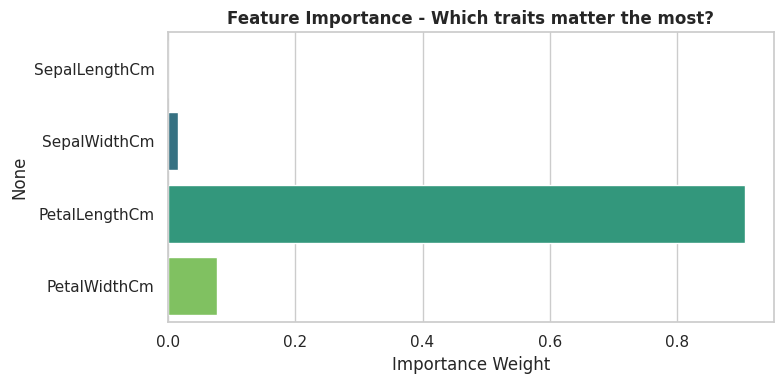

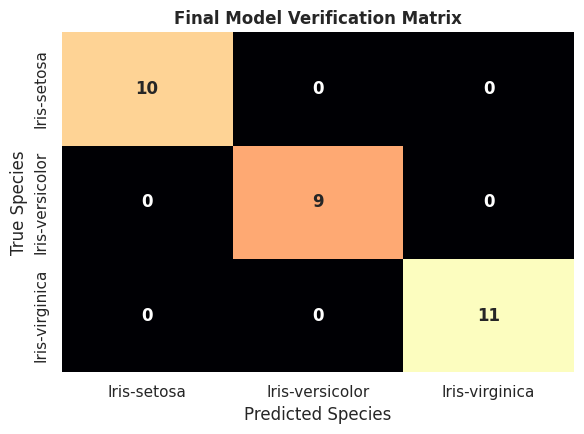


[SUCCESS]  'iris_production_model.pkl' saved!


In [4]:

import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. DATA LOAD AND SPLIT 
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

# ID drop karo AND Features & Target 
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. MULTIPLE MODELS TEST ENGINE
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(kernel='linear')
}

accuracies = {}

print("====== MODEL PERFORMANCE REPORT ======")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies[name] = acc
    print(f"{name:<25} -> Accuracy: {acc*100:.2f}%")
print("======================================\n")

# ==========================================
# 3. CHART 1: MODELS ACCURACY COMPARISON
# ==========================================
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='coolwarm')
plt.title('Machine Learning Model Benchmarking', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0.85, 1.05)

# Bars ke upar percentages likhne ke liye
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 4. CHART 2: FEATURE IMPORTANCE
# ==========================================
dt_model = models['Decision Tree']
importances = dt_model.feature_importances_

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Feature Importance - Which traits matter the most?', fontsize=12, fontweight='bold')
plt.xlabel('Importance Weight')
plt.tight_layout()
plt.show()

# ==========================================
# 5. CHART 3: ADVANCED CONFUSION MATRIX
# ==========================================
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=False,
            xticklabels=best_model.classes_, yticklabels=best_model.classes_,
            annot_kws={"size": 12, "weight": "bold"})
plt.xlabel('Predicted Species')
plt.ylabel('True Species')
plt.title('Final Model Verification Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 6. MODEL EXPORT 
# ==========================================
with open('iris_production_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("\n[SUCCESS]  'iris_production_model.pkl' saved!")

# **Interative Animation**

In [5]:
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Data load and model training
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
importances = dt_model.feature_importances_

# 2. ANIMATION DATASET GENERATE 
# Hum 20 alag-alag timesteps (frames) banayenge jisme bars dheere-dheere badhenge
animated_data = []
for frame in range(1, 21):
    for col, imp in zip(X.columns, importances):
        animated_data.append({
            'Features': col,
            # Har frame ke sath importance value linear badhegi
            'Importance Weight': imp * (frame / 20.0),
            'Video_Timeline': f"Step {frame}"
        })

animation_df = pd.DataFrame(animated_data)

# 3. INTERACTIVE ANIMATED CHART PLOT
fig = px.bar(
    animation_df, 
    x='Importance Weight', 
    y='Features',
    color='Importance Weight',
    orientation='h',
    title='<b>🎥 Live Analytics Engine: Feature Importance Loading...</b>',
    # YEH HAI MAGIC LINE: Isse neeche video play button aayega
    animation_frame='Video_Timeline', 
    range_x=[0, max(importances) + 0.05],
    color_continuous_scale='Viridis'
)

# Dark sleek look setup
fig.update_layout(
    template='plotly_dark',
    title_font_size=16,
    hovermode='closest'
)

fig.show()